# 第一章：最小可行进化器

**系列：** OpenEvolve — 从零到专家·手撕全流程  
**上一章：** [第零章 — 为什么要做这个项目](./00-why-this-project.ipynb)  
**本章内容：** 用大约 80 行代码构建最简单的进化代码优化器。没有 MAP-Elites、没有岛屿、没有 LLM——只有核心循环。

---

## 这一步解决什么问题？

在构建完整的 OpenEvolve 系统之前，我们需要理解**核心进化循环**——能有意义地"进化"代码的最简单系统。

本章我们构建的系统会：
1. 从一个初始程序开始
2. 生成随机变异
3. 评估每个变异版本
4. 保留更好的那个
5. 重复

这叫做 **(1+1) 进化策略**：一个父代、一个子代、留下更好的。它是最简单的进化策略，OpenEvolve 中所有东西都是它的扩展。

### 为什么从这么简单开始？

OpenEvolve 有大约 7,000 行代码。如果试图一次性理解全部，我们会淹死。从核心循环开始，我们能：
- 理解每一步**需要发生什么**
- 亲身**感受痛点**——这些痛点就是后续每个特性的动机
- 拥有一个可对比的工作基线

## 理论：(1+1) 进化策略

最简单的进化算法本质上就是爬山法（Hill Climbing）：

$$
\begin{aligned}
& \textbf{算法：} \text{ (1+1)-ES} \\
& \textbf{输入：} \text{ 初始程序 } x_0, \text{ 评估函数 } f \\
& \textbf{for } t = 1, 2, \ldots, T: \\
& \quad x' \leftarrow \text{mutate}(x_t) \quad \text{// 生成子代} \\
& \quad \textbf{if } f(x') > f(x_t): \quad \text{// 子代更优} \\
& \quad \quad x_{t+1} \leftarrow x' \quad \text{// 保留子代} \\
& \quad \textbf{else:} \\
& \quad \quad x_{t+1} \leftarrow x_t \quad \text{// 保留父代} \\
& \textbf{return } x_T
\end{aligned}
$$

这保证了单调递增（永远不会变差），但会**陷入局部最优**——第二章的 MAP-Elites 会解决这个问题。

> **出处：** Rechenberg, I. (1973). *Evolutionsstrategie: Optimierung technischer Systeme nach Prinzipien der biologischen Evolution.*  
> **对应原始代码：** `openevolve/controller.py` — `run()` 循环是这个算法的精心扩展版。

## 贯穿例子：进化一个排序算法

回顾第零章：我们用排序算法作为贯穿全文的例子。这是我们的起点——一个正确但缓慢的**冒泡排序**：

In [1]:
# 我们的初始程序：正确但很慢的冒泡排序
INITIAL_PROGRAM = '''
def sort_function(arr):
    """将数字列表按升序排列。"""
    arr = list(arr)  # 不修改原始数据
    n = len(arr)
    for i in range(n):
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr
'''

print(INITIAL_PROGRAM)


def sort_function(arr):
    """将数字列表按升序排列。"""
    arr = list(arr)  # 不修改原始数据
    n = len(arr)
    for i in range(n):
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr



## 第一步：评估器

在进化代码之前，我们需要一种方法来**给代码打分**。在 OpenEvolve 中，这就是 `Evaluator`——一个运行程序并返回指标的函数。

我们的评估器检查两件事：
1. **正确性** — 它真的能排序吗？
2. **速度** — 在 1000 个随机元素上有多快？

> **设计决策：** 我们把正确性和速度分开，因为快但错的程序毫无用处。在 OpenEvolve 中，这对应级联评估的概念——阶段 1 检查正确性，阶段 2 检查性能。我们会在第五章正式引入。

In [3]:
import time
import random
import math

def evaluate(program_code: str) -> dict:
    """
    评估一个排序程序。返回指标字典。
    
    这是最简单的评估器：
    - 在沙箱中执行代码（就是一个 dict）
    - 在已知输入上测试正确性
    - 在随机输入上测量速度
    - 返回综合分数
    
    在 OpenEvolve 中：evaluator.py 用子进程、超时和 3 个级联阶段来做这件事。
    我们后面会达到那个程度。
    """
    # 执行程序代码以获取函数
    namespace = {}
    try:
        exec(program_code, namespace)
    except Exception as e:
        return {"score": 0.0, "correct": False, "error": str(e)}
    
    sort_fn = namespace.get("sort_function")
    if sort_fn is None:
        return {"score": 0.0, "correct": False, "error": "未定义 sort_function"}
    
    # 在已知测试用例上检查正确性
    test_cases = [
        ([], []),
        ([1], [1]),
        ([3, 1, 2], [1, 2, 3]),
        ([5, 4, 3, 2, 1], [1, 2, 3, 4, 5]),
        ([1, 1, 1], [1, 1, 1]),
    ]
    for input_list, expected in test_cases:
        try:
            result = sort_fn(input_list)
            if result != expected:
                return {"score": 0.0, "correct": False, "error": f"{input_list} 的输出错误"}
        except Exception as e:
            return {"score": 0.0, "correct": False, "error": str(e)}
    
    # 在随机列表上测量速度（取 3 次平均值）
    test_data = [random.random() for _ in range(1000)]
    times = []
    for _ in range(3):
        start = time.perf_counter()
        sort_fn(test_data)
        elapsed = time.perf_counter() - start
        times.append(elapsed)
    
    avg_time = sum(times) / len(times)
    
    # 分数：越快越高。用 1/(1+time) 使分数在 (0, 1] 范围内
    speed_score = 1.0 / (1.0 + avg_time * 100)  # 缩放时间使差异可见
    
    return {
        "score": speed_score,
        "correct": True,
        "avg_time_ms": avg_time * 1000,
    }

# 用初始程序测试
result = evaluate(INITIAL_PROGRAM)
print(f"初始程序: score={result['score']:.4f}, 时间={result['avg_time_ms']:.1f}ms, 正确={result['correct']}")

初始程序: score=0.1201, 时间=73.3ms, 正确=True


## 第二步：程序存储

我们需要跟踪已经见过的程序。在完整的 OpenEvolve 中，这是一个带 MAP-Elites 网格、岛屿和精英档案的 `ProgramDatabase`。现在我们只用一个列表：

> **设计决策：** 一个简单列表加 `best` 指针。这是能做选择的最小数据结构。我们会在第 5 步看到收敛问题——那个痛点就是第二章 MAP-Elites 的动机。

In [9]:
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class Program:
    """一个已进化的程序及其评估结果。
    
    对应 OpenEvolve：database.py 定义了一个丰富得多的 Program 数据类，
    包含代数跟踪、岛屿归属、工件和父代谱系。
    我们会在需要的时候逐步添加。
    """
    code: str
    metrics: dict = field(default_factory=dict)
    generation: int = 0
    parent_id: Optional[int] = None


class ProgramStore:
    """最小程序存储——带最优跟踪的列表。
    
    对应 OpenEvolve：ProgramDatabase 使用每个岛屿各一个 MAP-Elites 网格。
    这个平铺列表是我们的起点；很快我们就会感受到它的局限。
    """
    def __init__(self):
        self.programs: list[Program] = []
        self.best: Optional[Program] = None
    
    def add(self, program: Program):
        self.programs.append(program)
        score = program.metrics.get("score", 0.0)
        if self.best is None or score > self.best.metrics.get("score", 0.0):
            self.best = program
    
    def sample_parent(self) -> Program:
        """随机均匀选择。粗糙但简单。
        
        对应 OpenEvolve：database.py 有 3 种策略——
        探索（随机）、利用（精英档案）、混合。
        我们会在第三章添加。
        """
        return random.choice(self.programs)
    
    def __len__(self):
        return len(self.programs)

print("ProgramStore 已就绪")

ProgramStore 已就绪


## 第三步：变异器

这是 OpenEvolve 使用 LLM 生成有意义代码改动的地方。我们还没到那一步——第四章才会加入 LLM。

现在我们用**随机字符串变异**——交换行、改常量、复制代码块。这很糟糕（大多数变异会产生坏代码），但这是诚实的起点，展示了*为什么 LLM 很重要*。

> **关键洞察：** 随机变异的糟糕质量正是 OpenEvolve 使用 LLM 的全部原因。学完这一章，你再也不会问"为什么不直接随机改代码？"——因为你会*亲眼看到*那有多糟。

In [11]:
def mutate_random(code: str) -> str:
    """生成代码的随机变异。
    
    策略（随机选择）：
    1. 交换两行
    2. 复制一行
    3. 删除一行
    4. 改变一个数字常量
    
    大多数变异会破坏程序——这正是重点。
    评估器会捕获坏程序（score=0）。
    
    对应 OpenEvolve：llm/ensemble.py 调用理解代码语义的 LLM。
    LLM 生成有意义的 diff。我们会在第四章替换这个函数。
    """
    lines = code.strip().split('\n')
    if len(lines) < 3:
        return code
    
    strategy = random.choice(["swap", "duplicate", "delete", "change_number"])
    
    if strategy == "swap":
        # 交换两个随机行（不动函数定义行）
        body_lines = list(range(1, len(lines)))
        if len(body_lines) >= 2:
            i, j = random.sample(body_lines, 2)
            lines[i], lines[j] = lines[j], lines[i]
    
    elif strategy == "duplicate":
        # 复制一个随机行
        idx = random.randint(1, len(lines) - 1)
        lines.insert(idx, lines[idx])
    
    elif strategy == "delete":
        # 删除一个随机行（至少保留 3 行）
        if len(lines) > 3:
            idx = random.randint(1, len(lines) - 1)
            lines.pop(idx)
    
    elif strategy == "change_number":
        # 找到含数字的行并修改
        import re
        for idx in range(1, len(lines)):
            numbers = re.findall(r'\b(\d+)\b', lines[idx])
            if numbers:
                old_num = random.choice(numbers)
                new_num = str(max(0, int(old_num) + random.randint(-2, 2)))
                lines[idx] = lines[idx].replace(old_num, new_num, 1)
                break
    
    return '\n'.join(lines)

# 演示：展示 3 个变异
for i in range(3):
    mutated = mutate_random(INITIAL_PROGRAM)
    result = evaluate(mutated)
    status = f"score={result['score']:.4f}" if result['correct'] else f"已损坏: {result.get('error', '?')[:50]}"
    print(f"变异 {i+1}: {status}")

变异 1: 已损坏: expected an indented block after 'for' statement o
变异 2: 已损坏: [] 的输出错误
变异 3: score=0.1600


## 第四步：核心进化循环

现在把所有东西组装成最简单的进化循环。这是 OpenEvolve `Controller.run()` 的骨架：

```mermaid
flowchart LR
    A[采样父代] --> B[变异]
    B --> C[评估]
    C --> D{更好？}
    D -->|是| E[存储]
    D -->|否| F[丢弃]
    E --> A
    F --> A
```

In [13]:
def run_evolution(
    initial_code: str,
    evaluator_fn,
    mutator_fn,
    iterations: int = 200,
) -> tuple[Program, list[dict]]:
    """核心进化循环——带种群的 (1+1)-ES。
    
    直接对应 OpenEvolve 的 Controller.run():
    - 采样父代       → controller 调用 database.sample()
    - 变异           → controller 调用 llm.generate()
    - 评估           → controller 调用 evaluator.evaluate()
    - 好则存储       → controller 调用 database.add()
    
    返回:
        best_program: 找到的最高分程序
        history: {iteration, best_score, population_size} 字典列表
    """
    store = ProgramStore()
    history = []
    
    # 评估并存储初始程序
    initial_metrics = evaluator_fn(initial_code)
    initial_program = Program(code=initial_code, metrics=initial_metrics, generation=0)
    store.add(initial_program)
    
    improvements = 0
    broken_count = 0
    
    for i in range(iterations):
        # 1. 采样父代
        parent = store.sample_parent()
        
        # 2. 变异
        child_code = mutator_fn(parent.code)
        
        # 3. 评估
        child_metrics = evaluator_fn(child_code)
        
        # 4. 如果正确则存储（我们保留所有正确的程序）
        if child_metrics.get("correct", False):
            child = Program(
                code=child_code,
                metrics=child_metrics,
                generation=parent.generation + 1,
                parent_id=id(parent),
            )
            store.add(child)
            
            if child_metrics["score"] > parent.metrics.get("score", 0):
                improvements += 1
        else:
            broken_count += 1
        
        # 记录进展
        history.append({
            "iteration": i,
            "best_score": store.best.metrics["score"],
            "best_time_ms": store.best.metrics.get("avg_time_ms", 0),
            "population_size": len(store),
        })
        
        if (i + 1) % 50 == 0:
            print(f"  [{i+1}/{iterations}] 最优={store.best.metrics['score']:.4f}, "
                  f"种群={len(store)}, 改进={improvements}, 损坏={broken_count}")
    
    print(f"\n完成！{improvements} 次改进，{broken_count}/{iterations} 次变异产生了坏代码")
    return store.best, history

print("run_evolution() 已就绪")

run_evolution() 已就绪


## 第五步：跑起来！

看看 200 次随机变异能做到什么：

In [15]:
random.seed(42)  # 可重复性 — OpenEvolve 默认也用 seed=42

print("正在用随机变异进化排序算法...\n")
best, history = run_evolution(
    initial_code=INITIAL_PROGRAM,
    evaluator_fn=evaluate,
    mutator_fn=mutate_random,
    iterations=200,
)

print(f"\n最优程序 (score={best.metrics['score']:.4f}, "
      f"时间={best.metrics.get('avg_time_ms', 0):.1f}ms):")
print(best.code)

正在用随机变异进化排序算法...

  [50/200] 最优=0.2364, 种群=18, 改进=14, 损坏=33
  [100/200] 最优=0.2392, 种群=35, 改进=23, 损坏=66
  [150/200] 最优=0.2392, 种群=50, 改进=31, 损坏=101
  [200/200] 最优=0.2392, 种群=65, 改进=36, 损坏=136

完成！36 次改进，136/200 次变异产生了坏代码

最优程序 (score=0.2392, 时间=31.8ms):
def sort_function(arr):
    """将数字列表按升序排列。"""
    n = len(arr)
    for i in range(n):
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr


C:\Users\zjq\AppData\Local\Temp\ipykernel_35352\1807880646.py:24: UserWarning: Glyph 36845 (\N{CJK UNIFIED IDEOGRAPH-8FED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjq\AppData\Local\Temp\ipykernel_35352\1807880646.py:24: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjq\AppData\Local\Temp\ipykernel_35352\1807880646.py:24: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjq\AppData\Local\Temp\ipykernel_35352\1807880646.py:24: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjq\AppData\Local\Temp\ipykernel_35352\1807880646.py:24: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zjq\AppData\Local\Temp\ipykernel_35352\1807880646.py:24: UserWarning: Glyph 20248 (\N{CJK UNIFIE

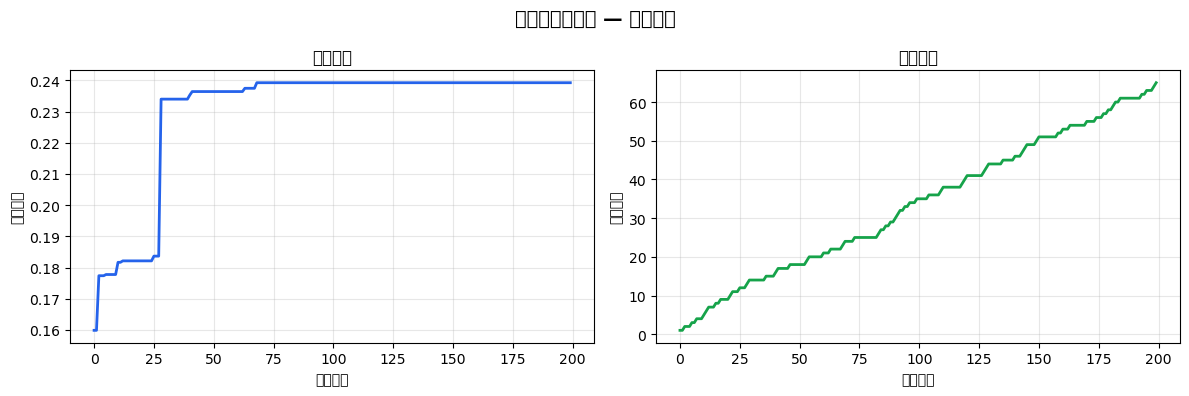

起始分数: 0.1599
最终分数: 0.2392
提升幅度: +49.6%


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

iters = [h["iteration"] for h in history]
scores = [h["best_score"] for h in history]
pop_sizes = [h["population_size"] for h in history]

# 图 1：最优分数随时间变化
axes[0].plot(iters, scores, linewidth=2, color="#2563eb")
axes[0].set_xlabel("迭代次数")
axes[0].set_ylabel("最优分数")
axes[0].set_title("进化进展")
axes[0].grid(True, alpha=0.3)

# 图 2：种群大小
axes[1].plot(iters, pop_sizes, linewidth=2, color="#16a34a")
axes[1].set_xlabel("迭代次数")
axes[1].set_ylabel("种群大小")
axes[1].set_title("种群增长")
axes[1].grid(True, alpha=0.3)

plt.suptitle("最小可行进化器 — 随机变异", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"起始分数: {history[0]['best_score']:.4f}")
print(f"最终分数: {history[-1]['best_score']:.4f}")
improvement_pct = (history[-1]['best_score'] - history[0]['best_score']) / history[0]['best_score'] * 100
print(f"提升幅度: {improvement_pct:+.1f}%")

## 我们学到了什么（以及什么让人痛苦）

看看上面的分数曲线。你大概会看到：

1. **大多数变异是坏的** — 随机字符串编辑通常产生语法错误或错误结果。这就是 OpenEvolve 用 LLM 的原因（第四章）。

2. **分数几乎不提升** — 我们在一个随机景观上爬山。随机交换行不会产生本质不同的排序算法。

3. **没有多样性** — 所有存活程序都是冒泡排序的微小变体。我们从未发现插入排序或归并排序。这就是需要 MAP-Elites 的原因（第二章）——它显式地维护*不同种类*的解。

4. **种群增长但没帮助** — 我们存储每个正确的程序，但采样是随机的。更好的选择策略会聚焦在有前途的区域。OpenEvolve 用开发/探索采样（第三章）。

### OpenEvolve 特性路线图

我们刚才感受到的每个局限，都对应一个特性：

| 痛点 | 对应特性 | 章节 |
|------|----------|------|
| 大多数变异破坏代码 | LLM 作为变异器 | 04 |
| 解没有多样性 | MAP-Elites 网格 | 02 |
| 陷入局部最优 | 岛屿种群 | 03 |
| 评估坏程序浪费时间 | 级联评估 | 05 |
| 未利用 diff 结构 | 基于 Diff 的进化 | 06 |
| 单线程 | 进程并行 | 07 |

## 与 OpenEvolve 原始代码的对应关系

我们构建的每一部分都直接对应 OpenEvolve：

| 我们的代码 | OpenEvolve | 文件:行号 |
|-----------|------------|----------|
| `Program` 数据类 | `Program` 数据类 | `database.py:L32-L65` |
| `ProgramStore` | `ProgramDatabase` | `database.py:L150+` |
| `ProgramStore.add()` | `ProgramDatabase.add_program()` | `database.py:L400+` |
| `ProgramStore.sample_parent()` | `ProgramDatabase._sample_parent()` | `database.py:L600+` |
| `evaluate()` | `Evaluator.evaluate()` | `evaluator.py:L80+` |
| `mutate_random()` | `LLMEnsemble.generate()` | `llm/ensemble.py:L50+` |
| `run_evolution()` | `Controller.run()` | `controller.py:L200+` |

## 保存到 `our-implementation/`

把代码写成正式模块，后续章节可以直接 import：

In [19]:
import os

MODULE_CODE = '''
"""our-implementation/core.py — 最小进化代码优化器。

在第一章中构建，后续章节会扩展。
"""
import random
import time
from dataclasses import dataclass, field
from typing import Optional, Callable


@dataclass
class Program:
    """一个已进化的程序及其评估结果。"""
    code: str
    metrics: dict = field(default_factory=dict)
    generation: int = 0
    parent_id: Optional[int] = None


class ProgramStore:
    """最小程序存储——带最优跟踪的列表。"""
    def __init__(self):
        self.programs: list[Program] = []
        self.best: Optional[Program] = None

    def add(self, program: Program):
        self.programs.append(program)
        score = program.metrics.get("score", 0.0)
        if self.best is None or score > self.best.metrics.get("score", 0.0):
            self.best = program

    def sample_parent(self) -> Program:
        return random.choice(self.programs)

    def __len__(self):
        return len(self.programs)


def run_evolution(
    initial_code: str,
    evaluator_fn: Callable[[str], dict],
    mutator_fn: Callable[[str], str],
    iterations: int = 200,
) -> tuple[Program, list[dict]]:
    """核心 (1+1)-ES 进化循环。"""
    store = ProgramStore()
    history = []
    initial_metrics = evaluator_fn(initial_code)
    store.add(Program(code=initial_code, metrics=initial_metrics, generation=0))

    for i in range(iterations):
        parent = store.sample_parent()
        child_code = mutator_fn(parent.code)
        child_metrics = evaluator_fn(child_code)

        if child_metrics.get("correct", False):
            child = Program(
                code=child_code,
                metrics=child_metrics,
                generation=parent.generation + 1,
                parent_id=id(parent),
            )
            store.add(child)

        history.append({
            "iteration": i,
            "best_score": store.best.metrics["score"],
            "population_size": len(store),
        })

    return store.best, history
'''

os.makedirs("../our-implementation", exist_ok=True)

with open("../our-implementation/__init__.py", "w") as f:
    f.write("# OpenEvolve 从零手撕版\n")

with open("../our-implementation/core.py", "w") as f:
    f.write(MODULE_CODE)

print("✓ 已保存 our-implementation/core.py")
print("  导出: Program, ProgramStore, run_evolution")

✓ 已保存 our-implementation/core.py
  导出: Program, ProgramStore, run_evolution


## 本章总结

用大约 80 行真实代码，我们构建了进化代码优化器的核心：

- **`Program`** — 存储代码+指标（对应 `database.py:Program`）
- **`ProgramStore`** — 存储种群、跟踪最优（对应 `database.py:ProgramDatabase`）
- **`evaluate()`** — 正确性+速度打分（对应 `evaluator.py:Evaluator`）
- **`run_evolution()`** — 核心循环（对应 `controller.py:Controller.run()`）

### 关键收获

1. 进化需要三个要素：**种群**、**变异**、**选择**
2. 随机变异*非常糟糕*——大多数直接破坏代码
3. 即使变异成功了，种群也会收敛——没有多样性
4. 我们感受到的每个局限都对应 OpenEvolve 的一个具体特性

**下一章：** [第二章 — MAP-Elites](./02-map-elites.ipynb)  
我们将添加质量-多样性网格，维护*不同种类*的解，解决收敛问题。